In [9]:
from lab1pyver import environment, MABe_agent
import numpy as np

In [10]:
Envir = environment(8,8)
Envir.map_Designate(17,56,-15)
Envir.map_Designate(18,56,-15)
Envir.map_Designate(19,56,-15)
Envir.map_Designate(21,56,-15)
Envir.map_Designate(25,56,-15)
Envir.map_Designate(33,56,-15)
Envir.map_Designate(41,56,-15)
Envir.map_Designate(42,56,-15)
Envir.map_Designate(43,56,-15)
Envir.map_Designate(46,56,-15)
Envir.map_Designate(47,56,-15)
Envir.map_Designate(47,56,-15)
Envir.map_Designate(15,56,+15)
Envir.map_Designate(1,10,+5)
Envir.map_Designate(26,56,+20)

In [11]:
q_agent = MABe_agent(envir=Envir, init_location=12, epsilon = 0.3, lr = 0.05, gamma = 0.95)

In [12]:
num_iter = 10000
log_freq = 100
Data_plot_q_agent = []

for i in range(num_iter):
  env_observation = (None, Envir.action_space, None)
  if i > 0:
    env_observation = Envir.get_Observation(location=q_agent.cur_location, action=chosen_action)

  chosen_action = q_agent.getAction(observation=env_observation)
  if (i + 1) % log_freq == 0:
    aver = np.mean(q_agent.rewards)
    Data_plot_q_agent.append(aver)
    print('iter: ' + str(i + 1) + '\t Total reward: ' + str(q_agent.getTotalReward()) + '\t Average: ' + str(aver))


iter: 100	 Total reward: 0	 Average: 0.0
iter: 200	 Total reward: -10	 Average: -0.05025125628140704
iter: 300	 Total reward: 70	 Average: 0.23411371237458195
iter: 400	 Total reward: 120	 Average: 0.3007518796992481
iter: 500	 Total reward: 105	 Average: 0.21042084168336672
iter: 600	 Total reward: 230	 Average: 0.38397328881469117
iter: 700	 Total reward: 240	 Average: 0.34334763948497854
iter: 800	 Total reward: 185	 Average: 0.23153942428035043
iter: 900	 Total reward: 135	 Average: 0.15016685205784205
iter: 1000	 Total reward: 180	 Average: 0.18018018018018017
iter: 1100	 Total reward: 250	 Average: 0.22747952684258416
iter: 1200	 Total reward: 275	 Average: 0.22935779816513763
iter: 1300	 Total reward: 325	 Average: 0.2501924557351809
iter: 1400	 Total reward: 385	 Average: 0.27519656897784134
iter: 1500	 Total reward: 465	 Average: 0.31020680453635757
iter: 1600	 Total reward: 480	 Average: 0.300187617260788
iter: 1700	 Total reward: 505	 Average: 0.2972336668628605
iter: 1800	 

In [13]:
import numpy as np

class SARSA_agent(MABe_agent):
    def __init__(self, envir, init_location, epsilon, lr, gamma):
        super().__init__(envir, init_location, epsilon, lr, gamma)
        self.lr = lr
        self.gamma = gamma
        self.q_table = {}
        self.last_action = None
        self.last_location = None

    def getAction(self, observation):
        location_now, action_space, pre_reward = observation
        if location_now is not None:
            self.cur_location = location_now
        if location_now not in self.q_table:
            self.q_table[location_now] = [0.0] * len(action_space)
        rand_val = np.random.rand()
        if rand_val < self.threshold_greedy:
            next_action = np.random.choice(action_space)
        else:
            next_action = np.argmax(self.q_table[location_now])
        if pre_reward is not None and self.last_location is not None:
            old_q = self.q_table[self.last_location][self.last_action]
            next_q_value = self.q_table[location_now][next_action]
            self.q_table[self.last_location][self.last_action] = (1 - self.lr) * old_q + self.lr * (pre_reward + self.gamma * next_q_value)
            self.rewards.append(pre_reward)
        self.last_location = location_now
        self.last_action = next_action 
        return next_action

Điểm khác biệt chính của sarsa và q learning là q value luôn được cập nhật dựa trên giá trị ước lượng lớn nhất của q value trong state tiếp theo, sarsa thì không dựa trên action có giá trị ước lượng q lớn nhất trong state tiếp theo mà dựa trên hành động mà nó thực sự làm. Điểm khác biệt trong đoạn code là khỉ random ra 1 action khác so với action có q max trong state tiếp theo, sarsa sẽ lấy q value với action đó để cập nhật, còn q learning thì sử dụng q max dù cho hành động được chọn không phải là hành động argmax

sarsa roll hành động trước rồi cập nhật giá trị của s,a sau dựa trên val của state mới và hành động mới được roll ra, q thì chỉ cần biết state mới và auto chọn action argmax

sarsa kiểu phải chọn action trước rồi update value sau, còn q thì update trước chọn action sau

In [14]:
sarsa_agent = SARSA_agent(envir=Envir, init_location=12, epsilon = 0.3, lr = 0.05, gamma = 0.95)

In [15]:
num_iter = 10000
log_freq = 100
Data_plot_sarsa_agent = []

for i in range(num_iter):
  env_observation = (None, Envir.action_space, None)
  if i > 0:
    env_observation = Envir.get_Observation(location=sarsa_agent.cur_location, action=chosen_action)

  chosen_action = sarsa_agent.getAction(observation=env_observation)
  if (i + 1) % log_freq == 0:
    aver = np.mean(sarsa_agent.rewards)
    Data_plot_sarsa_agent.append(aver)
    print('iter: ' + str(i + 1) + '\t Total reward: ' + str(sarsa_agent.getTotalReward()) + '\t Average: ' + str(aver))

iter: 100	 Total reward: -45	 Average: -0.45918367346938777
iter: 200	 Total reward: -50	 Average: -0.25252525252525254
iter: 300	 Total reward: -50	 Average: -0.16778523489932887
iter: 400	 Total reward: -70	 Average: -0.17587939698492464
iter: 500	 Total reward: -10	 Average: -0.020080321285140562
iter: 600	 Total reward: 90	 Average: 0.1505016722408027
iter: 700	 Total reward: 195	 Average: 0.2793696275071633
iter: 800	 Total reward: 255	 Average: 0.31954887218045114
iter: 900	 Total reward: 320	 Average: 0.35634743875278396
iter: 1000	 Total reward: 255	 Average: 0.25551102204408815
iter: 1100	 Total reward: 365	 Average: 0.3324225865209472
iter: 1200	 Total reward: 410	 Average: 0.34223706176961605
iter: 1300	 Total reward: 455	 Average: 0.3505392912172573
iter: 1400	 Total reward: 575	 Average: 0.4113018597997139
iter: 1500	 Total reward: 695	 Average: 0.46395193591455275
iter: 1600	 Total reward: 750	 Average: 0.4693366708385482
iter: 1700	 Total reward: 860	 Average: 0.50647820

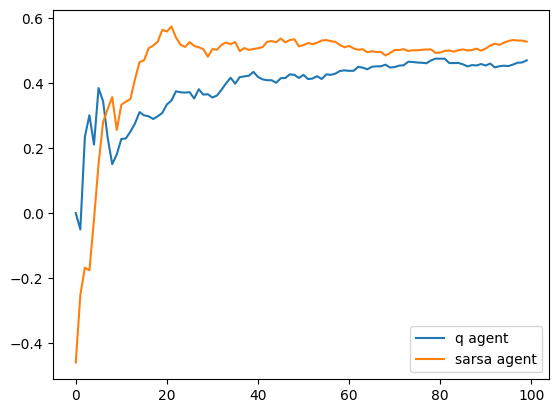

In [16]:
import matplotlib.pyplot as plt

fig = plt.figure()
plt.plot(Data_plot_q_agent, label="q agent")
plt.plot(Data_plot_sarsa_agent, label="sarsa agent")
plt.legend()
plt.show()